In [29]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

In [78]:
def number_of_decimals(number):
    a = number
    for i in range(20):
        if a > 1:
            return i
        a *= 10
    return 20

def plot_pdf(x, pdf1, pdf2, sum_pdf, mean1, mean2, std1, std2, xb):
    # Plotting
    plt.plot(x, pdf1, label=f'Normal(mean={mean1}, std={std1})')
    plt.plot(x, pdf2, label=f'Normal(mean={mean2}, std={std2})')
    plt.plot(x, sum_pdf, label='Sum of both distributions', linestyle='--')

    plt.title("Summation of Two Normal Distributions")
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    step_size = np.around(xb/4, max(1, number_of_decimals(xb/4)-1))
    plt.xticks(np.arange(-xb, xb+step_size, step_size))
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_cdf(half_x, abs_cdf, xb):
    # Plotting the CDF of the absolute value of the sum_pdf
    plt.plot(half_x, abs_cdf, label='CDF of Abs(Sum PDF)', color='purple')
    plt.title("CDF of the Absolute Value of Summed Distribution")
    plt.xlabel('x')
    step_size = np.around(xb/10, number_of_decimals(xb/10))
    plt.xticks(np.arange(0, xb+step_size, step_size))
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.ylabel('Cumulative Probability')
    plt.legend()
    plt.grid(True)
    plt.show()

In [79]:
def generate_mixtures(mean1, mean2, std1, std2, plot=True):
    xb = std2*2.5
    xb = np.around(xb, number_of_decimals(xb))
    n_elements = 1000
    # Generate points on the x axis
    x = np.linspace(-xb, xb, n_elements)

    # Calculate the PDFs for the two normal distributions
    pdf1 = norm.pdf(x, mean1, std1)
    pdf2 = norm.pdf(x, mean2, std2)

    # Summation of the two normal distributions
    sum_pdf = (pdf1 + pdf2)/2
    abs_pdf = 2*sum_pdf[n_elements//2:]
    # Calculate the CDF of the absolute value PDF
    half_x = x[n_elements//2:]
    abs_cdf = np.cumsum(abs_pdf) * (half_x[1] - half_x[0])

    if plot:
        plot_pdf(x, pdf1, pdf2, sum_pdf, mean1, mean2, std1, std2, xb)
        plot_cdf(half_x, abs_cdf, xb)


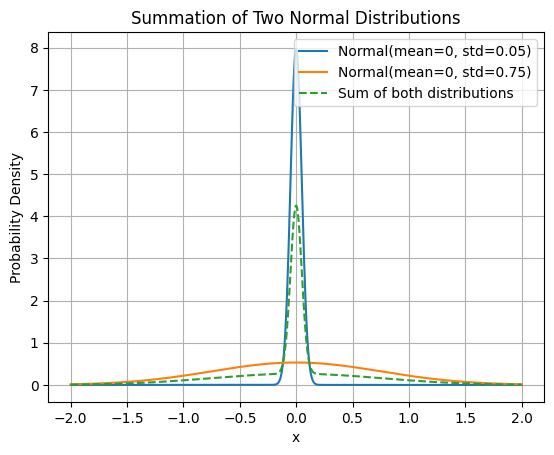

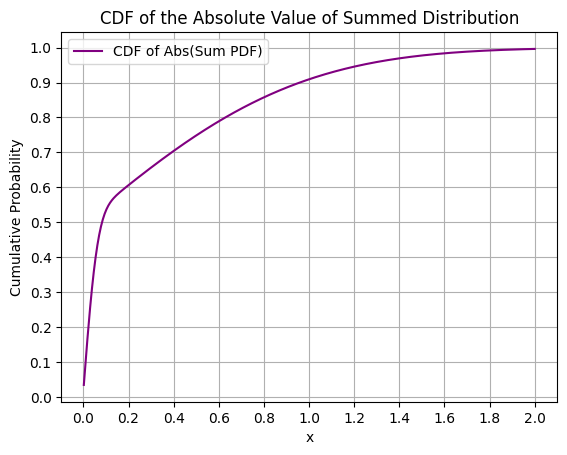

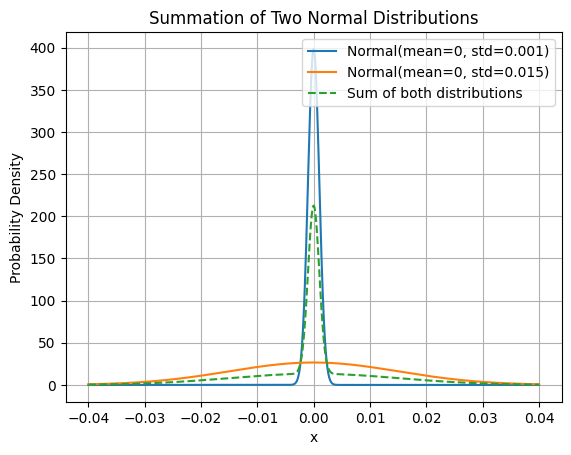

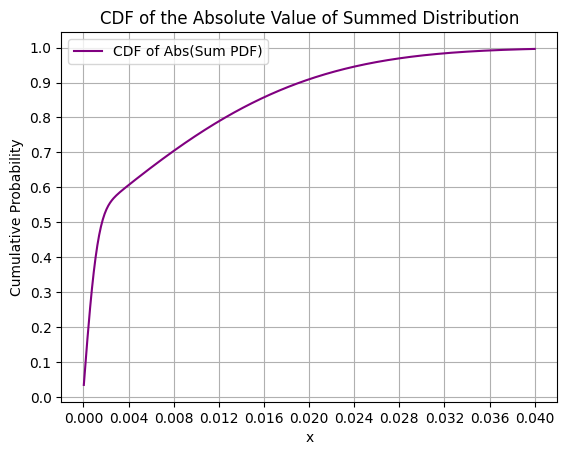

In [80]:
# TRANSLATIONAL PDF AND CDF
generate_mixtures(mean1=0, mean2=0, std1=0.05, std2=0.75, plot=True)
# ROTATIONAL PDF AND CDF
generate_mixtures(mean1=0, mean2=0, std1=0.0010, std2=0.015, plot=True)

